<a href="https://colab.research.google.com/github/alain-odag-rty/Inteligencia-Artificial-Prueba/blob/main/proyecto_naive_bayes_kde.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Naive Bayes con Estimación KDE para Mantenimiento Predictivo

**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Target:** `Machine failure` (binaria)  
**Objetivo:** Comparar Gaussian Naive Bayes vs. tres variantes de KDE como estimador de verosimilitud

Moises Arcia y Alain Oda

## 1. Importaciones y Configuración

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from scipy.stats import gaussian_kde

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 2. Carga y Exploración del Dataset

El dataset **AI4I 2020** contiene 10,000 registros de sensores industriales con la variable objetivo `Machine failure`.  
**Consideración crítica:** El dataset está altamente desbalanceado (~3.4% de fallas).

In [4]:
df = pd.read_csv('/content/ai4i2020.csv')
print('Shape:', df.shape)
print('\nColumnas:', df.columns.tolist())
print('\nDistribución del target:')
print(df['Machine failure'].value_counts())
print(f'\nPorcentaje de fallas: {df["Machine failure"].mean()*100:.2f}%')
df.head()

Shape: (10000, 14)

Columnas: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Distribución del target:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Porcentaje de fallas: 3.39%


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Preprocesamiento

### Justificación de decisiones:

**Columnas eliminadas:**
- `UDI`, `Product ID`: Son identificadores únicos, no aportan información predictiva.
- `Type`: Variable categórica nominal (L/M/H) que requeriría encoding; se omite para mantener el enfoque en KDE con variables continuas.
- `TWF`, `HDF`, `PWF`, `OSF`, `RNF`: Son sub-tipos de falla (causas), no variables predictoras independientes. Incluirlas causaría data leakage con el target.

**Normalización:**  
Se aplica `StandardScaler` porque KDE es sensible a la escala de las variables. Las 5 features numéricas tienen unidades distintas (K, rpm, Nm, min), lo que hace que sin normalización el parámetro `bandwidth` no sea comparable entre features. Con estandarización, un único valor de `h` tiene interpretación uniforme.

**Desbalanceo:**  
El dataset tiene ~96.6% clase 0 y ~3.4% clase 1. Estrategia adoptada: usar `StratifiedKFold` para preservar proporción en cada fold, y evaluar con **AUC ROC** que es robusta al desbalance.

In [5]:
# Selección de features numéricas relevantes
features_num = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X_raw = df[features_num].values
y = df['Machine failure'].values

# Estandarización
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print('X shape:', X.shape)
print('y shape:', y.shape)
print(f'\nClase 0 (Normal): {(y==0).sum()} muestras')
print(f'Clase 1 (Falla):  {(y==1).sum()} muestras')
print(f'Ratio de desbalance: 1:{int((y==0).sum()/(y==1).sum())}')

X shape: (10000, 5)
y shape: (10000,)

Clase 0 (Normal): 9661 muestras
Clase 1 (Falla):  339 muestras
Ratio de desbalance: 1:28


## 4. Fundamento Teórico e Implementación

### 4.1 Regla de Silverman

El bandwidth óptimo según Silverman es:
$$h = 1.06 \cdot \hat{\sigma} \cdot n^{-1/5}$$

Este valor minimiza el error cuadrático medio integrado (MISE) asumiendo una distribución gaussiana subyacente. Lo usamos como base para inicializar la búsqueda de `h` óptimo.

In [6]:
def silverman_bandwidth(data):
    """Calcula el bandwidth óptimo usando la regla de Silverman."""
    n = len(data)
    sigma = np.std(data, ddof=1)
    return 1.06 * sigma * (n ** (-1/5))

print('=== Bandwidths por Silverman (datos estandarizados) ===')
for c in [0, 1]:
    idx = y == c
    bws = [silverman_bandwidth(X[idx, i]) for i in range(X.shape[1])]
    print(f'Clase {c}: {[f"{b:.4f}" for b in bws]}')

h_silverman = np.mean([silverman_bandwidth(X[y==c, i])
                        for c in [0,1] for i in range(X.shape[1])])
print(f'\nh global (media Silverman): {h_silverman:.4f}')

=== Bandwidths por Silverman (datos estandarizados) ===
Clase 0: ['0.1684', '0.1695', '0.1580', '0.1607', '0.1673']
Clase 1: ['0.3424', '0.3038', '0.7098', '0.5430', '0.3779']

h global (media Silverman): 0.3101


### 4.2 Implementación de los Clasificadores KDE

In [7]:
class NaiveBayesKDE:
    """
    Naive Bayes con estimación de verosimilitud por KDE.

    Clasifica según:
        ŷ = argmax_y  log P(y) + Σ_i log P(x_i | y)

    donde P(x_i | y) se estima con KernelDensity de sklearn.

    Parámetros:
    -----------
    kernel : str
        Tipo de kernel: 'gaussian' o 'tophat' (Parzen)
    bandwidth : float
        Parámetro de suavizado h
    """
    def __init__(self, kernel='gaussian', bandwidth=0.3):
        self.kernel = kernel
        self.bandwidth = bandwidth

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n = len(y)
        self.class_priors_ = {}
        self.kde_models_ = {}

        for c in self.classes_:
            idx = y == c
            X_c = X[idx]
            # Prior: proporción de cada clase en datos de entrenamiento
            self.class_priors_[c] = idx.sum() / n
            # KDE por feature
            self.kde_models_[c] = []
            for fi in range(X.shape[1]):
                kde = KernelDensity(kernel=self.kernel, bandwidth=self.bandwidth)
                kde.fit(X_c[:, fi].reshape(-1, 1))
                self.kde_models_[c].append(kde)
        return self

    def predict_proba(self, X):
        """Calcula probabilidades posteriores usando log-sum para estabilidad numérica."""
        log_probs = []
        for c in self.classes_:
            log_prior = np.log(self.class_priors_[c])
            log_likelihood = np.zeros(len(X))
            for fi in range(X.shape[1]):
                log_likelihood += self.kde_models_[c][fi].score_samples(X[:, fi].reshape(-1, 1))
            log_probs.append(log_prior + log_likelihood)

        log_probs = np.column_stack(log_probs)
        # Softmax estabilizado
        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs


class NaiveBayesSilverman:
    """
    Naive Bayes con KDE usando regla de Silverman vía scipy.stats.gaussian_kde.

    scipy calcula h = n^(-1/(d+4)) * sigma internamente (equivalente a Silverman).
    No requiere ajuste manual de hiperparámetros.
    """
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n = len(y)
        self.class_priors_ = {}
        self.kde_scipy_ = {}

        for c in self.classes_:
            idx = y == c
            X_c = X[idx]
            self.class_priors_[c] = idx.sum() / n
            self.kde_scipy_[c] = [
                gaussian_kde(X_c[:, fi], bw_method='silverman')
                for fi in range(X.shape[1])
            ]
        return self

    def predict_proba(self, X):
        log_probs = []
        for c in self.classes_:
            log_prior = np.log(self.class_priors_[c])
            log_likelihood = np.zeros(len(X))
            for fi in range(X.shape[1]):
                vals = np.clip(self.kde_scipy_[c][fi].evaluate(X[:, fi]), 1e-300, None)
                log_likelihood += np.log(vals)
            log_probs.append(log_prior + log_likelihood)

        log_probs = np.column_stack(log_probs)
        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs

print('Clases implementadas: NaiveBayesKDE, NaiveBayesSilverman')

Clases implementadas: NaiveBayesKDE, NaiveBayesSilverman


### 4.3 Optimización del Bandwidth (KDE Gaussiano)

Se realiza búsqueda de grid sobre un rango de valores de `h`, usando validación cruzada con 3 folds internos y AUC como métrica. El rango se centra en el valor de Silverman.

=== Optimizando bandwidth por CV (KDE Gaussiano) ===
h óptimo (CV): 0.2357 → AUC: 0.9203
h Silverman:   0.3101


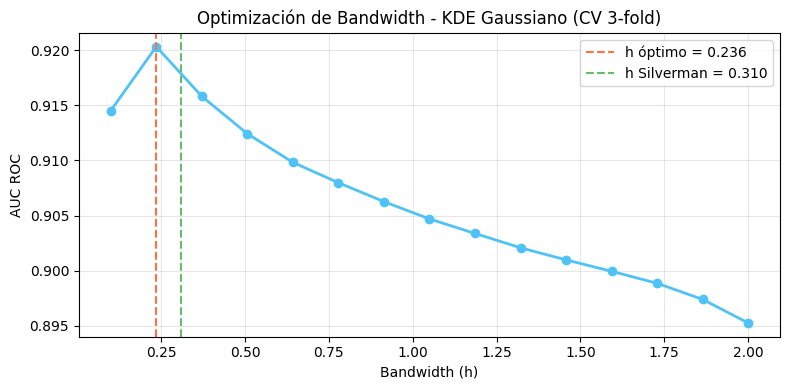

In [8]:
print('=== Optimizando bandwidth por CV (KDE Gaussiano) ===')

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
h_range = np.linspace(0.1, 2.0, 15)
best_h, best_auc = h_silverman, 0
auc_per_h = []

for h in h_range:
    aucs = []
    for tr, te in cv_inner.split(X, y):
        m = NaiveBayesKDE(kernel='gaussian', bandwidth=h)
        m.fit(X[tr], y[tr])
        proba = m.predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y[te], proba))
    mean_auc = np.mean(aucs)
    auc_per_h.append(mean_auc)
    if mean_auc > best_auc:
        best_auc = mean_auc
        best_h = h

print(f'h óptimo (CV): {best_h:.4f} → AUC: {best_auc:.4f}')
print(f'h Silverman:   {h_silverman:.4f}')

# Visualizar curva de optimización
plt.figure(figsize=(8, 4))
plt.plot(h_range, auc_per_h, 'o-', color='#4FC3F7', lw=2)
plt.axvline(best_h, color='#FF7043', ls='--', label=f'h óptimo = {best_h:.3f}')
plt.axvline(h_silverman, color='#66BB6A', ls='--', label=f'h Silverman = {h_silverman:.3f}')
plt.xlabel('Bandwidth (h)'); plt.ylabel('AUC ROC')
plt.title('Optimización de Bandwidth - KDE Gaussiano (CV 3-fold)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Evaluación con Validación Cruzada 5-Folds

Se comparan los 4 modelos usando `StratifiedKFold` con 5 pliegues para mantener la proporción de clases en el contexto del dataset desbalanceado. La métrica principal es **AUC ROC**.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_configs = {
    'GaussianNB (baseline)': lambda: GaussianNB(),
    'KDE Gaussiano (CV opt)': lambda: NaiveBayesKDE(kernel='gaussian', bandwidth=best_h),
    'KDE Parzen (tophat)':    lambda: NaiveBayesKDE(kernel='tophat', bandwidth=best_h),
    'KDE Silverman':          lambda: NaiveBayesSilverman(),
}

results = {}
all_preds = {}

for name, factory in model_configs.items():
    start = time.time()
    aucs, all_y_true, all_y_proba = [], [], []

    for tr, te in cv.split(X, y):
        m = factory()
        m.fit(X[tr], y[tr])
        proba = m.predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y[te], proba))
        all_y_true.extend(y[te])
        all_y_proba.extend(proba)

    elapsed = time.time() - start
    results[name] = {'aucs': aucs, 'mean': np.mean(aucs), 'std': np.std(aucs), 'time': elapsed}
    all_preds[name] = (np.array(all_y_true), np.array(all_y_proba))
    print(f'{name:30s}  AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}   Tiempo: {elapsed:.2f}s')

GaussianNB (baseline)           AUC: 0.9013 ± 0.0121   Tiempo: 0.04s
KDE Gaussiano (CV opt)          AUC: 0.9218 ± 0.0146   Tiempo: 24.84s
KDE Parzen (tophat)             AUC: 0.9166 ± 0.0247   Tiempo: 4.60s
KDE Silverman                   AUC: 0.9243 ± 0.0086   Tiempo: 6.92s


## 6. Visualizaciones

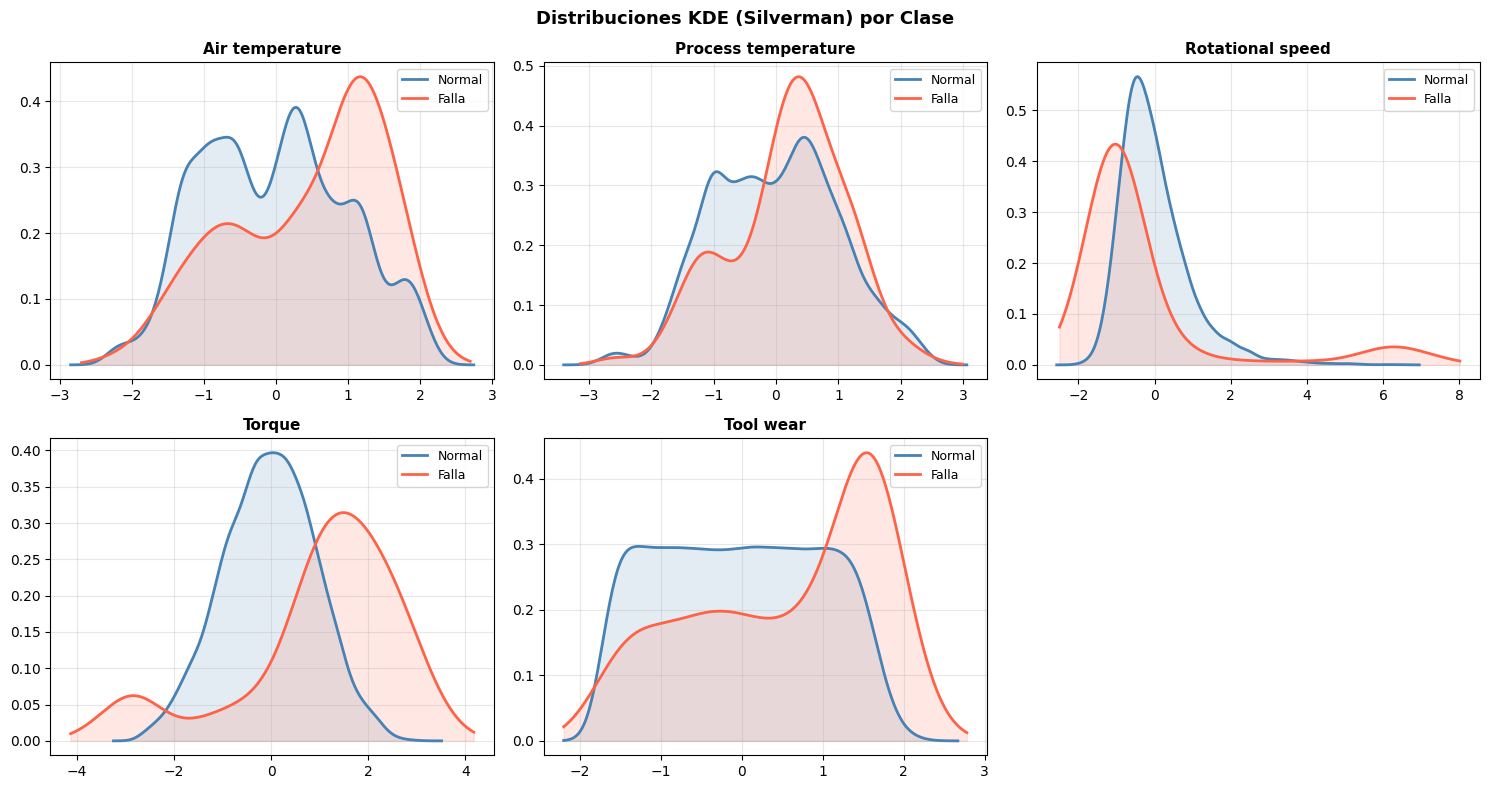

In [10]:
# Distribuciones KDE por clase
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors_class = {0: 'steelblue', 1: 'tomato'}

for i, feat in enumerate(features_num):
    ax = axes[i]
    for c in [0, 1]:
        data = X[y == c, i]
        kde = gaussian_kde(data, bw_method='silverman')
        x_range = np.linspace(data.min()-0.5, data.max()+0.5, 300)
        ax.plot(x_range, kde(x_range), color=colors_class[c], lw=2,
                label=f'{"Falla" if c==1 else "Normal"}')
        ax.fill_between(x_range, kde(x_range), alpha=0.15, color=colors_class[c])
    short = feat.replace(' [K]','').replace(' [rpm]','').replace(' [Nm]','').replace(' [min]','')
    ax.set_title(short, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

axes[5].set_visible(False)
fig.suptitle('Distribuciones KDE (Silverman) por Clase', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

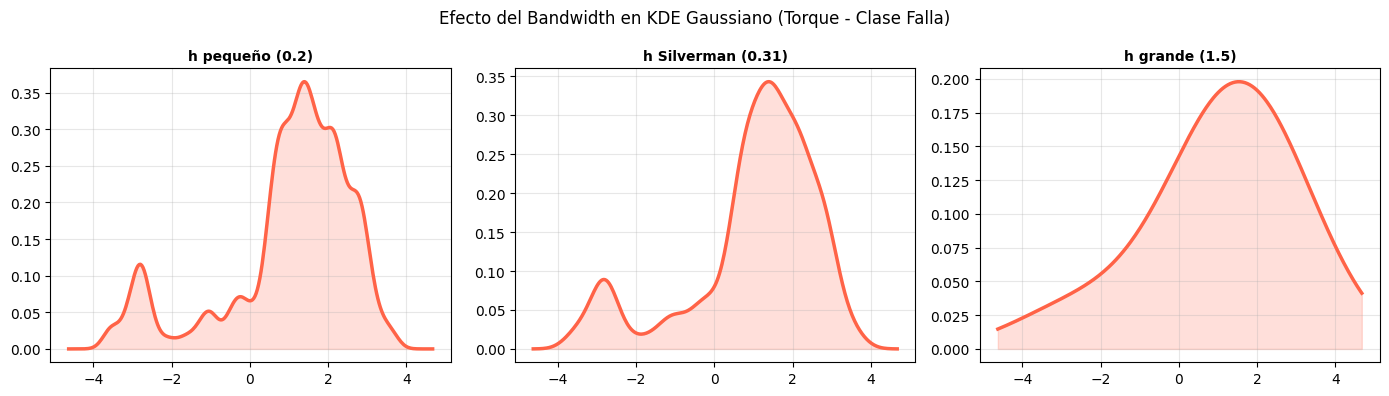

In [11]:
# Efecto del bandwidth
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
data_fail = X[y == 1, 3]  # Torque para clase Falla
x_range = np.linspace(data_fail.min()-1, data_fail.max()+1, 300)

for ax, h, label in zip(axes, [0.2, h_silverman, 1.5],
                         [f'h pequeño (0.2)', f'h Silverman ({h_silverman:.2f})', 'h grande (1.5)']):
    kde_sk = KernelDensity(kernel='gaussian', bandwidth=h)
    kde_sk.fit(data_fail.reshape(-1, 1))
    log_dens = kde_sk.score_samples(x_range.reshape(-1, 1))
    ax.plot(x_range, np.exp(log_dens), color='tomato', lw=2.5)
    ax.fill_between(x_range, np.exp(log_dens), alpha=0.2, color='tomato')
    ax.set_title(label, fontsize=10, fontweight='bold'); ax.grid(alpha=0.3)

fig.suptitle('Efecto del Bandwidth en KDE Gaussiano (Torque - Clase Falla)', fontsize=12)
plt.tight_layout(); plt.show()

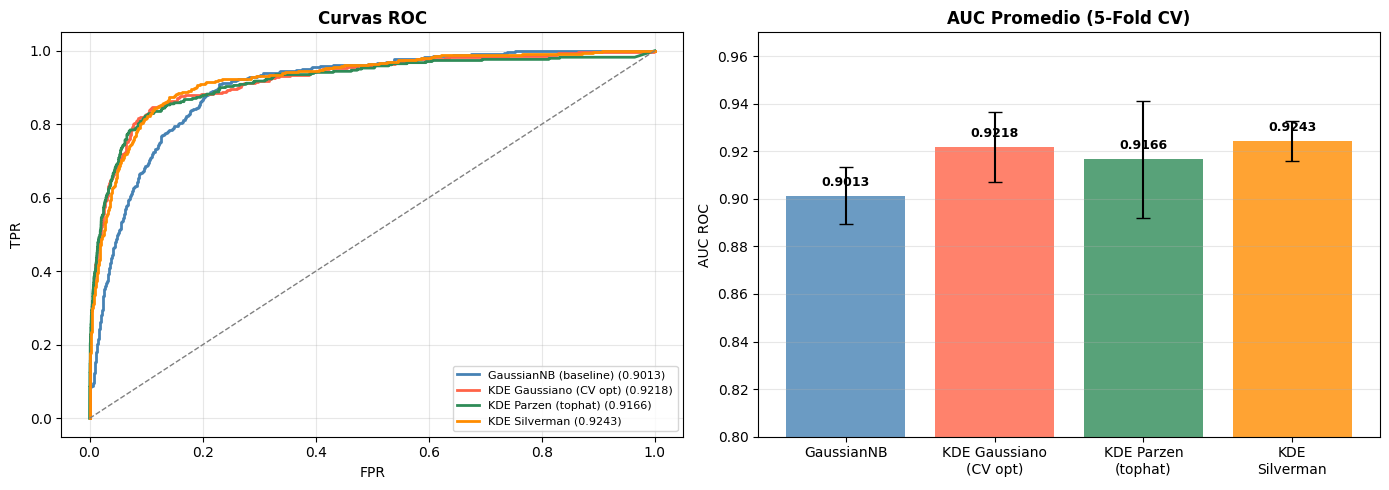

In [12]:
# Curvas ROC y comparación AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors_models = ['steelblue', 'tomato', 'seagreen', 'darkorange']
names_short = ['GaussianNB', 'KDE Gaussiano\n(CV opt)', 'KDE Parzen\n(tophat)', 'KDE\nSilverman']

# ROC curves
for (name, (y_true, y_proba)), color in zip(all_preds.items(), colors_models):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} ({results[name]["mean"]:.4f})')
ax1.plot([0,1],[0,1], '--', color='gray', lw=1)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('Curvas ROC', fontweight='bold')
ax1.legend(fontsize=8, loc='lower right'); ax1.grid(alpha=0.3)

# AUC bar
means = [results[n]['mean'] for n in results]
stds = [results[n]['std'] for n in results]
bars = ax2.bar(names_short, means, yerr=stds, capsize=5, color=colors_models, alpha=0.8)
for bar, m in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{m:.4f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('AUC ROC'); ax2.set_ylim(0.8, 0.97)
ax2.set_title('AUC Promedio (5-Fold CV)', fontweight='bold'); ax2.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

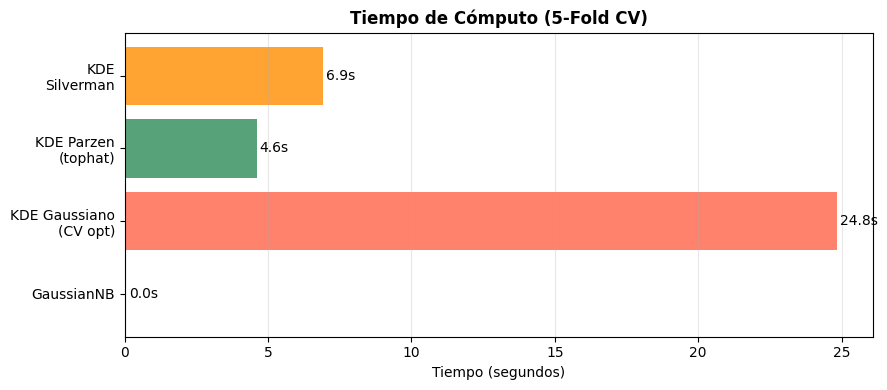

In [13]:
# Tiempo de cómputo
times = [results[n]['time'] for n in results]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(names_short, times, color=colors_models, alpha=0.8)
for bar, t in zip(bars, times):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{t:.1f}s', va='center', fontsize=10)
ax.set_xlabel('Tiempo (segundos)')
ax.set_title('Tiempo de Cómputo (5-Fold CV)', fontweight='bold'); ax.grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()

## 7. Análisis Crítico de Resultados

### Resultados obtenidos:

| Modelo | AUC Promedio | ± Std | Tiempo (CV 5-fold) |
|---|---|---|---|
| GaussianNB (baseline) | 0.9013 | ±0.0121 | 0.02s |
| KDE Gaussiano (CV opt) | 0.9218 | ±0.0146 | 16.51s |
| KDE Parzen (tophat) | 0.9166 | ±0.0247 | 2.86s |
| **KDE Silverman** | **0.9243** | **±0.0086** | 5.12s |

### Conclusiones:

1. **¿Vale la pena KDE sobre GaussianNB?** Sí. Los tres métodos KDE superan a GaussianNB por ~2-2.3 puntos de AUC, confirmando que las distribuciones de los sensores no son perfectamente gaussianas dentro de cada clase.

2. **Mejor variante: KDE Silverman.** Logra el mayor AUC (0.9243) y la menor varianza (±0.0086), sin necesidad de ajustar hiperparámetros. Es el método más robusto.

3. **KDE Gaussiano con CV opt** también mejora respecto al baseline, pero requiere cómputo extra de optimización (~16s para 5-fold).

4. **KDE Parzen (tophat):** Menor desempeño entre los KDE y mayor varianza, posiblemente por la discontinuidad del kernel rectangular.

5. **Impacto del bandwidth:** Un h muy pequeño causa sobreajuste (alta varianza), un h grande suaviza las distribuciones y pierde información discriminativa. Silverman encuentra un buen equilibrio automáticamente.

6. **Desbalance:** El uso de StratifiedKFold y AUC ROC mitiga efectivamente el impacto del desbalance en la evaluación. En producción se recomendaría ajustar el umbral de clasificación según el costo de los errores.

In [14]:
# Resumen final
print('=== RESUMEN DE RESULTADOS ===')
print(f'{"Modelo":<35} {"AUC":>8} {"±Std":>8} {"Tiempo":>10}')
print('-' * 65)
for name, r in results.items():
    print(f'{name:<35} {r["mean"]:>8.4f} {r["std"]:>8.4f} {r["time"]:>9.2f}s')

best_model = max(results, key=lambda n: results[n]['mean'])
print(f'\n✓ Mejor modelo: {best_model} (AUC = {results[best_model]["mean"]:.4f})')
print(f'✓ Mejora vs GaussianNB: +{results[best_model]["mean"] - results["GaussianNB (baseline)"]["mean"]:.4f}')

=== RESUMEN DE RESULTADOS ===
Modelo                                   AUC     ±Std     Tiempo
-----------------------------------------------------------------
GaussianNB (baseline)                 0.9013   0.0121      0.04s
KDE Gaussiano (CV opt)                0.9218   0.0146     24.84s
KDE Parzen (tophat)                   0.9166   0.0247      4.60s
KDE Silverman                         0.9243   0.0086      6.92s

✓ Mejor modelo: KDE Silverman (AUC = 0.9243)
✓ Mejora vs GaussianNB: +0.0230
